# Solution for exam - Candidate number 84
***

## Task 1
***

In [83]:
#Importing packages
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn.linear_model as skm

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)

from ISLP.models import ModelSpec as MS, summarize
from ISLP.transforms import BSpline

from sklearn.metrics import mean_squared_error

### a) Loading and splitting data
***

In [84]:
#Loading data
df = pd.read_csv('task1_data.csv')
print(df.shape)
df.head()

(5000, 7)


,x1,x2,x3,x4,x5,x6,y
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,6.847133
1,1.744812,-0.761207,0.319039,-0.249370,1.462108,-2.060141,5.975528
2,-0.322417,-0.384054,1.133769,-1.099891,-0.172428,-0.877858,2.137287
3,0.042214,0.582815,-1.100619,1.144724,0.901591,0.502494,5.908800
4,0.900856,-0.683728,-0.122890,-0.935769,-0.267888,0.530355,5.173577


In [85]:
#Predictors and response variable
predictors = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
X = df[predictors]   # design matrix: 5000 × 6, all numerical
y = df['y']          # continuous response y

In [86]:
#50/50 split
np.random.seed(123)
n      = len(df)
ind    = np.random.choice(np.arange(n), size= n // 2, replace = False)
mask   = np.ones(n, dtype=bool)
mask[ind] = False

X_train, X_test = X.iloc[ind], X.iloc[mask]
y_train, y_test = y.iloc[ind], y.iloc[mask]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'y: mean = {y_train.mean():.2f}, std = {y_train.std():.2f}')

Train: (2500, 6), Test: (2500, 6)
y: mean = 3.49, std = 3.42


### Interpretation

The data is split 50/50 into a training and test set. This is done to train the model on some data, and test it on unseen data, avoiding data leakage. If we didn't split data into training and testing the model would simply remember all the training points, overfitting the data. This would mean the model would generalize badly to new data, modelling noise rather than the signal. Model performance would be very good (low MSE), as it measures model performance on unseen data. 

### b) Initial data analysis
***

In [87]:
df.describe()

,x1,x2,x3,x4,x5,x6,y
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.005223,-0.006547,-0.003266,-0.005843,0.019770,-0.000129,3.501549
std,1.007704,0.986592,0.999976,0.994602,1.006470,0.997107,3.557777
min,-3.612812,-3.456765,-3.927514,-3.363736,-4.233165,-3.367947,-8.178315
25%,-0.701437,-0.661705,-0.683056,-0.677427,-0.651881,-0.667768,1.198418
50%,0.025374,-0.011046,-0.018935,-0.003986,0.027634,-0.008419,3.181076
75%,0.693518,0.646217,0.674484,0.648835,0.681222,0.655213,5.450556
max,3.404302,3.958603,3.613277,4.026849,4.168118,3.547680,54.247050


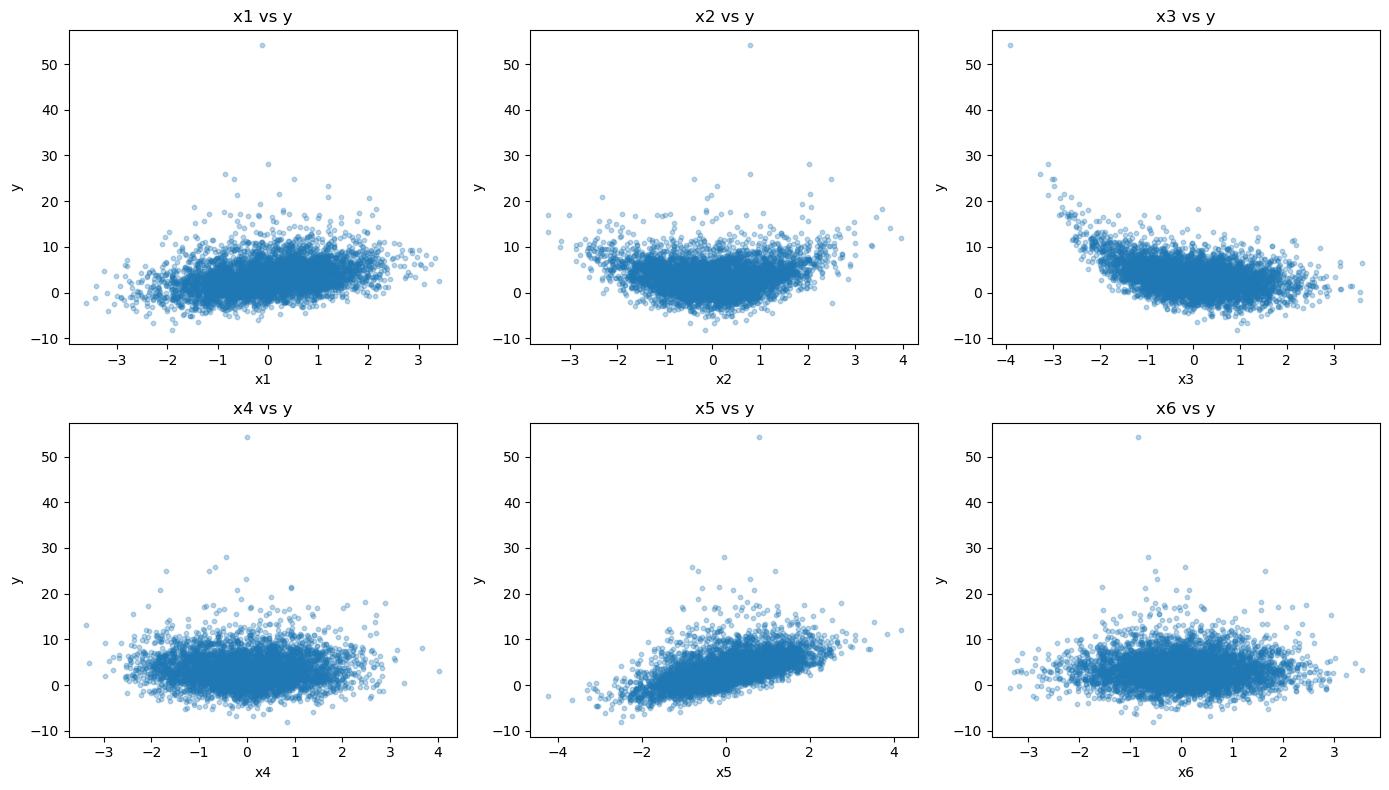

In [88]:
#Scatter plot to show relationship
fig, ax = plt.subplots(2, 3, figsize = (14, 8))

for ax, col in zip(ax.flatten(), predictors):
    ax.scatter(df[col], df['y'], alpha = 0.3, s = 10)
    ax.set_xlabel(col)
    ax.set_ylabel('y')
    ax.set_title(f"{col} vs y")

plt.tight_layout()
plt.show()

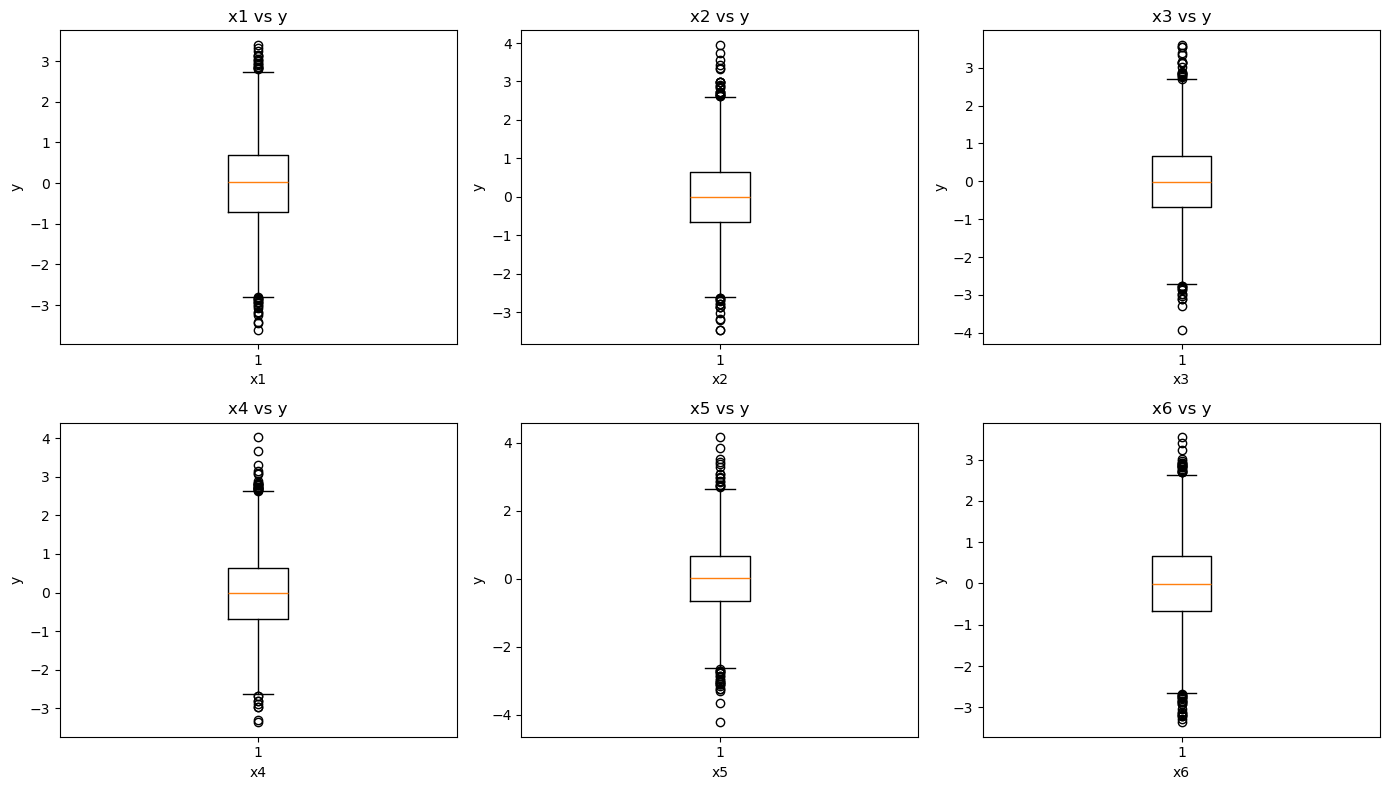

In [89]:
#Plot
fig, ax = plt.subplots(2, 3, figsize = (14, 8))

for ax, col in zip(ax.flatten(), predictors):
    ax.boxplot(df[col])
    ax.set_xlabel(col)
    ax.set_ylabel('y')
    ax.set_title(f"{col} vs y")

plt.tight_layout()
plt.show()

### Interpretation

From the plots we can see that variables `x1` and `x5` has a positive linear relationship with y, whilst `x3` has a negative linear relationship. The other variables `x2`, `x4` and `x6` appears to have a non-linear relationship. Both the plots and the `describe` function also shows us that y has a extrem value of 54,25, indicating non-linear aspects in the data.

### c) Linear regression
***

In [90]:
#OLS linear regression
X_train_c = sm.add_constant(X_train) #Adding constant as statsmodels doesn't do it automatically, to make intercept and avoid origo
ols = sm.OLS(y_train, X_train_c).fit()
print(ols.summary())  # coefficients, t-test, p-values, R², F-test

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     638.7
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        14:59:41   Log-Likelihood:                -5454.2
No. Observations:                2500   AIC:                         1.092e+04
Df Residuals:                    2493   BIC:                         1.096e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4378      0.043     79.985      0.0

In [91]:
#Testing and calculating test-mse
X_test_c = sm.add_constant(X_test)
pred_ols = ols.predict(X_test_c)

mse_ols  = np.mean((y_test - pred_ols) ** 2)
print(f'Test MSE (OLS): {mse_ols:.4f}')

Test MSE (OLS): 5.3684


In [92]:
#Training mse
train_mse_ols = mean_squared_error(y_train, pred_ols)
print(f"Training MSE (OLS): {train_mse_ols:.4f}")

Training MSE (OLS): 18.6068


### Interpretation

OLS minimizes RSS (residual sum of squares) without giving any penalties. This means that coefficients are allowed to be big, with the risk of some variables having a unreasonably large effect on the prediction. 

From the summary table we can see that variables `x1`, `x3` and `x5` are statistically significant ($p < 0.05$). `x5` (coefficient = 1.93) and `x3` (coefficient = -1.51) has the biggest effect on the variable y, with `x1` having a moderate effect (coefficient = 1.03). This means that a one unit increase in `x5` increases y with 1.93, and a one unit increase in `x3` decreases y by -1.51. The remaining variables has coefficients around 0, indicating a small but linear effect, although these are not statistically significant. $R^2 = 0.61$ indicates that the model explains ≈ 60% of the variance in the data, which is not particulary high. This again indicates that there are non-linear relationships that the linear regression is unable to capture.

### d) GAM
***

In [93]:
# #GAM
# for i, col in enumerate():
#     xi      = X[:, i]
#     r2_lin  = sm.OLS(y, sm.add_constant(xi)).fit().rsquared
#     Xq      = sm.add_constant(np.column_stack([xi, xi**2]))
#     r2_quad = sm.OLS(y, Xq).fit().rsquared
#     print(col, round(r2_quad - r2_lin, 3))

# #GAM with BSpline
# bs   = BSpline(internal_knots=[-1, 0, 1], degree=3, intercept=False)
# X_sp = bs.fit_transform(X[:, 2].reshape(-1, 1)) 
# X_gam = np.column_stack([np.ones(len(y)),
#                          X[:, :2],
#                          X_sp,               
#                          X[:, 2+1:]])
# gam = sm.OLS(y, X_gam).fit()
# print(f'GAM R²: {gam.rsquared:.4f}')

#Couldnt finish

### e) Explaining code
***

In [94]:
def mse(beta, X, y):
    return np.mean((y - X @ beta) ** 2)

### Interpretation

The code is the function for calculating the mean of squared errors, given as the average of $(y_i - x_i\beta)^2$. This function is used to calculate the sum of squared residuals for the Ridge-regression, given as $\sum_i(y_i - x_i\beta)^2 + \lambda\sum_j\beta_j^2$. This indicates the performance of the model. 

$\beta$ is the penalty variable, forcing coeffisients towards zero. As ridge uses squared penalty (where Lasso uses absolute values), the coefficients never actually reach zero. Higher values of $\beta$ minimizes the function. This is helpful if the predictors are correlated, there are more variables than observations or the model overfits (high variance). Paired with $\lambda$, these regularise the model. With $\lambda = 0$, Ridge is doing the same as OLS, minimizing RSS. This is known as the bias-vairance tradeoff, where a low $\lambda$ makes the model more flexible decreasing bias, but increasing variance.

### f) Polynomial
***

### Interpretation

A regression with higher powers of x allows the linear model to capture curved (non-linear) relationships in the data. For each extra degree of power, the model is allowed additional flexibility and bends, to adjust even further to the data. 

If the test MSE is a lot higher than train MSE, the model overfits and memorizes data and noise, and is unable to generalize to new, unseen data. This indicates a too complex model, with too many degrees of power. If train and test MSE is equal, the model is too simple, as it does not capture the signal of the training data. To adjust this, the model can be made more flexible by adding polynomial degrees, as it better generalizes to test-data (to a certain point). This highlights the bias-variance trade-off. A low degree (simple model) introduces bias, and a high degree polynomial overfits, increasing variance. 

## Task 2
***

### a) Loading data and descriptive statistics
***

In [95]:
#Load data
df = pd.read_csv('customer_data.csv')
print(df.shape)
print(df['Churn'].value_counts())
df.head()

(2666, 20)
Churn
False    2278
True      388
Name: count, dtype: int64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [96]:
#Churn rate in dataset
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean():.4f}")

Churn
False    2278
True      388
Name: count, dtype: int64
Churn rate: 0.1455


In [97]:
#Correlation. Same for eve, night and intl
correlation_day = df['Total day charge'] / df['Total day minutes']

correlation_day

0       0.170011
1       0.169988
2       0.170008
3       0.170007
4       0.170006
          ...   
2661    0.170007
2662    0.169974
2663    0.170013
2664    0.170022
2665    0.170009
Length: 2666, dtype: float64

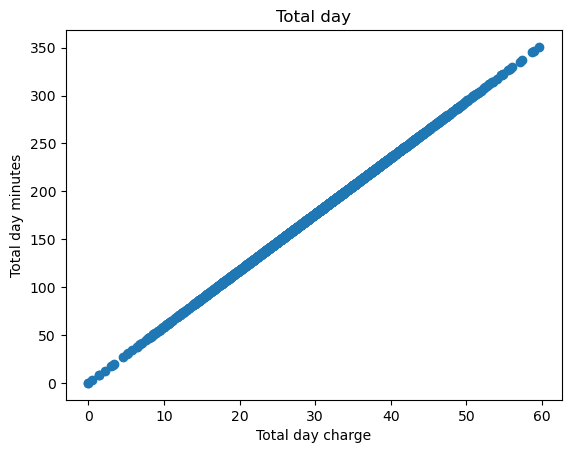

In [98]:
#Plot to show perfect correlation
plt.scatter(df['Total day charge'], df['Total day minutes'])
plt.xlabel('Total day charge')
plt.ylabel('Total day minutes')
plt.title('Total day')
plt.show()

In [99]:
#Drop leakage variables (charge = minutes * rate, perfectly correlated)
#and State (50 categories, too high cardinality)
df_model = df.drop(columns=[
    'State',
    'Total day charge',    # = Total day minutes * 0.17
    'Total eve charge',    # = Total eve minutes * 0.085
    'Total night charge',  # = Total night minutes * 0.045
    'Total intl charge'    # = Total intl minutes * 0.27
])

df_model

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,415,No,No,0,134.7,98,189.7,68,221.4,128,11.8,5,2,False
2662,192,415,No,Yes,36,156.2,77,215.5,126,279.1,83,9.9,6,2,False
2663,68,415,No,No,0,231.1,57,153.4,55,191.3,123,9.6,4,3,False
2664,28,510,No,No,0,180.8,109,288.8,58,191.9,91,14.1,6,2,False


In [100]:
#Convert Churn bool to int
df_model['Churn'] = df_model['Churn'].astype(int)

In [101]:
#Create dummies for categorical variables (drop_first avoids the dummy trap)
df_model = pd.get_dummies(
    df_model,
    columns = ['Area code', 'International plan', 'Voice mail plan'],
    drop_first = True,
    dtype = int
)
print(df_model.shape)

(2666, 16)


In [102]:
#Split data 50/50
np.random.seed(123)
n      = len(df_model)
ind    = np.random.choice(np.arange(n), size = n // 2, replace=False)
mask   = np.ones(n, dtype=bool)
mask[ind] = False

train = df_model.iloc[ind]
test  = df_model.iloc[mask]

X_train = train.drop(columns='Churn')
y_train = train['Churn']
X_test  = test.drop(columns='Churn')
y_test  = test['Churn']

In [103]:
#Descriptive statistics
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.4f}, test: {y_test.mean():.4f}')

Train: (1333, 15), Test: (1333, 15)
Churn rate train: 0.1508, test: 0.1403


In [104]:
#Categorical predictors
for col in ['International plan', 'Voice mail plan']:
    cm = pd.crosstab(df[col], df['Churn'], normalize = 'index').round(3) #normalize = index for (Churn / plan-status)
    print(f"\n{col} (row proportions):")
    print(cm)


International plan (row proportions):
Churn               False  True 
International plan              
No                  0.887  0.113
Yes                 0.563  0.437

Voice mail plan (row proportions):
Churn            False  True 
Voice mail plan              
No               0.833  0.167
Yes              0.911  0.089


### Interpretation

From the print above we can see that customers with international plans churn far more often, with a churn rate of 43.7%, compared to 11.3% for customers without it. 

For voicemail-customers, the picture is more evenly spread; customers with the voice mail plan has only 8.9% churn rate, compared to 16.7% for those who doesn't have it. 

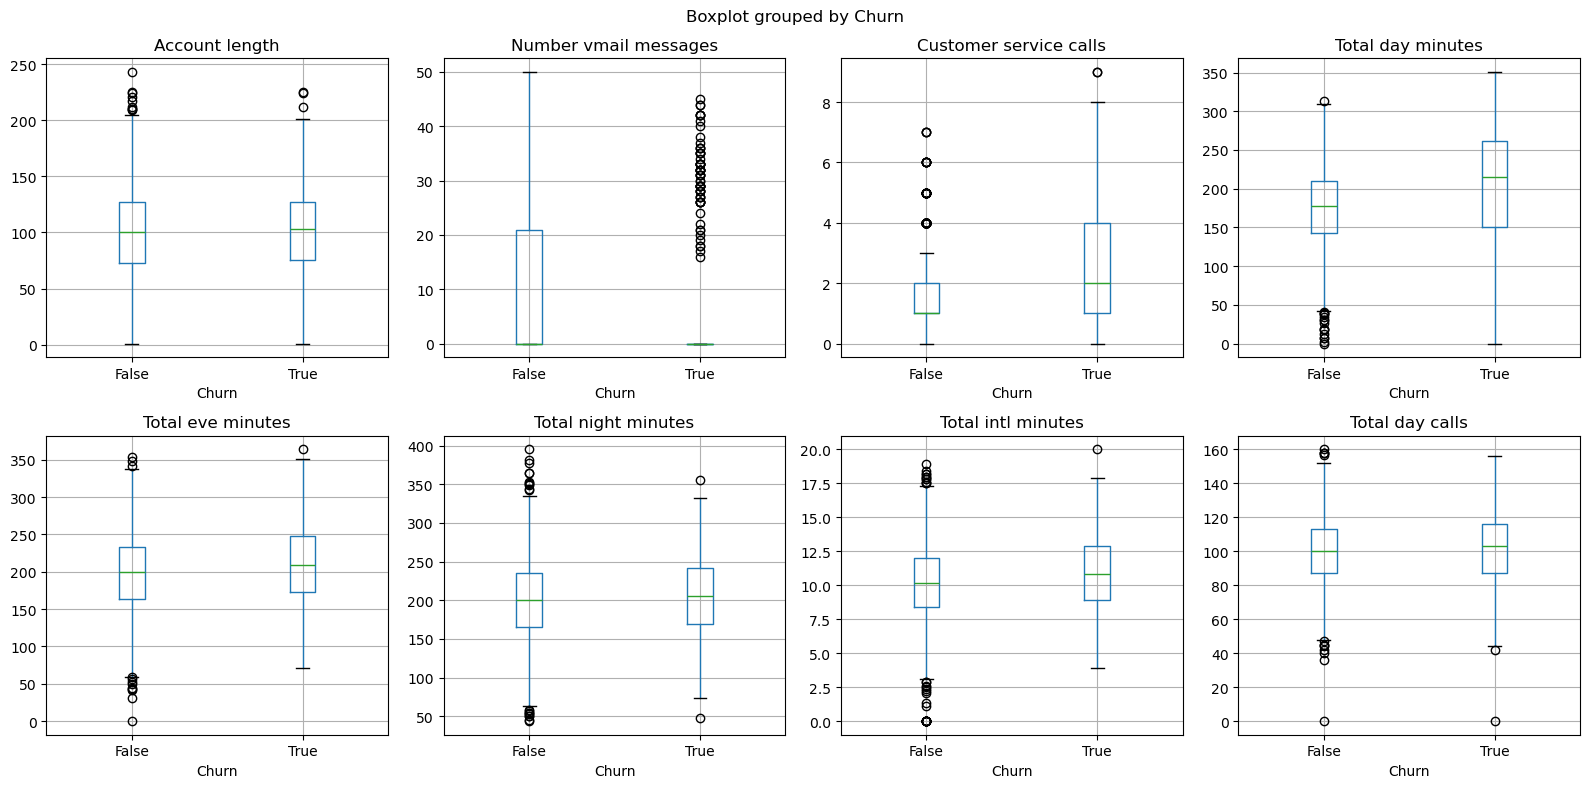

In [105]:
#Numerical predictors
num_cols = [
    'Account length', 'Number vmail messages', 'Customer service calls', 'Total day minutes', 'Total eve minutes', 'Total night minutes', 'Total intl minutes', 'Total day calls'
]

fig, ax = plt.subplots(2, 4, figsize = (16, 8))
for ax, col in zip(ax.flatten(), num_cols):
    df.boxplot(column = col, by = 'Churn', ax = ax)

    ax.set_title(col)
    ax.set_xlabel('Churn')

plt.tight_layout()
plt.show()

### Interpretation

From the boxplot we can see that `customer service calls` has a big difference between customers that churn to those who doesnt. "Churners" calls customer service more often than "non-churners". Churners also use daytime more often, as seen on `Total day minutes`. `Account length`, `Total eve minutes`, `Total night minutes`, and `Total intl minutes` appears to have smaller differences between churners and non-churners. `Total day calls` appears to be almost identical for both groups.

For these reasons, we can identify `customer service calls` and `International plan_Yes` as particulary important for predicting churn.

### b) Logistic regression
***

In [106]:
#Fitting model
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

logreg = sm.GLM(y_train, X_train_c, family=sm.families.Binomial()).fit()
print(logreg.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 1333
Model:                            GLM   Df Residuals:                     1317
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -442.88
Date:                Tue, 19 May 2026   Deviance:                       885.76
Time:                        14:59:44   Pearson chi2:                 1.26e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1678
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -7

In [107]:
#Predicting logistic regression
prob  = logreg.predict(X_test_c)
pred  = (prob > 0.5).astype(int) #Classification at 0.5

print(f"Prediction of classification:")
print(pred.value_counts())

mse_log = np.sum((y_test - pred) ** 2)
print(f"MSE for logistic regression: {mse_log:.4f}")

Prediction of classification:
0    1257
1      76
Name: count, dtype: int64
MSE for logistic regression: 177.0000


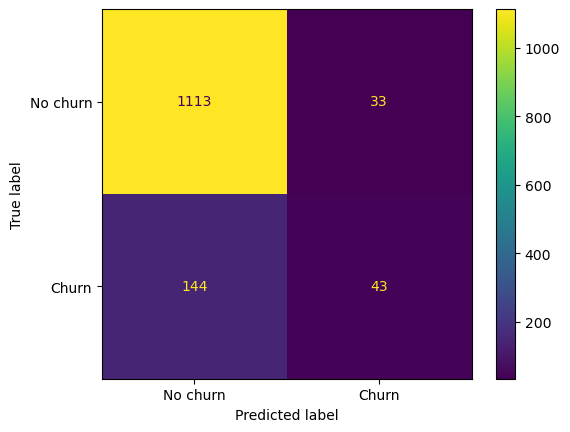

In [108]:
#Confusion matrix
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No churn', 'Churn'])
disp.plot()
plt.show()

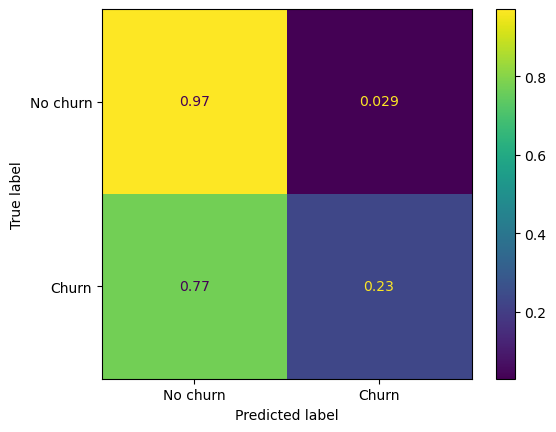

Accuracy: 0.8672


In [109]:
#Confusion matrix 2
cm2 = confusion_matrix(y_test, pred, normalize = 'true')
disp2 = ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels = ['No churn', 'Churn'])
disp2.plot()
plt.show()

accuracy_logreg = np.mean(pred == y_test)
print(f'Accuracy: {accuracy_logreg:.4f}')

### Interpretation

The model used is a GLM model (Generalized linear model), with binomial family to use as logistic regression. The model has a accuracy of 86.72%, which is only slightly higher than the naive model, at 85,45%.

Significant predictors (p < 0.05) are `Customer service calls`, `International plan_Yes`, `Total day minutes`, `Total intl calls`, `Total intl minutes`, `Voice mail plan_Yes`, `Number vmail messages` and `Total eve minutes` and `Total night minutes`.

We see that `Customer service calls` has a major impact on the model, with a coefficient of 0.55. This means that for every additional customer service call, churn increases by 0.55. We also see that `International plan_Yes` has a coefficient of 1.96, and `Voicemail plan_yes` has a coefficient of -2.66. Every additional customer with voicemail-plan decreases churn by 2.66 units (given that all other variables are untouched).

Of a total of 187 churners, only 43 are predicted as shown in `cm`, indicating that the model is defensive in predicting chrun. 

With all variables used, the model is somewhat untidy and not so easy to interpret. Removing some variables, for examplem the non-significant ones could benefit the model.

### c) K-nearest neighbours (KNN)
***

In [110]:
#KNN
param_k  = {'n_neighbors' : (range(1, 21))}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_k, cv = 5, scoring = 'accuracy')
knn_grid.fit(X_train, y_train)
pred_knn  = knn_grid.predict(X_test)

print(f'Best K: {knn_grid.best_params_["n_neighbors"]}')

accuracy_knn = np.mean(pred_knn == y_test)
print(f'KNN Accuracy: {accuracy_knn:.4f}')

mse_knn = np.sum((y_test - pred_knn) ** 2)
print(f"MSE for KNN: {mse_knn:.4f}")

Best K: 6
KNN Accuracy: 0.8740
MSE for KNN: 168.0000


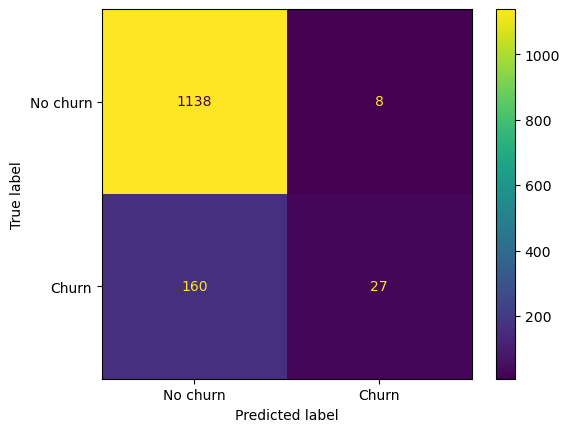

In [111]:
#Confusion matrix
cm_knn = confusion_matrix(y_test, pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix = cm_knn, display_labels = ['No churn', 'Churn'])
disp_knn.plot()
plt.show()

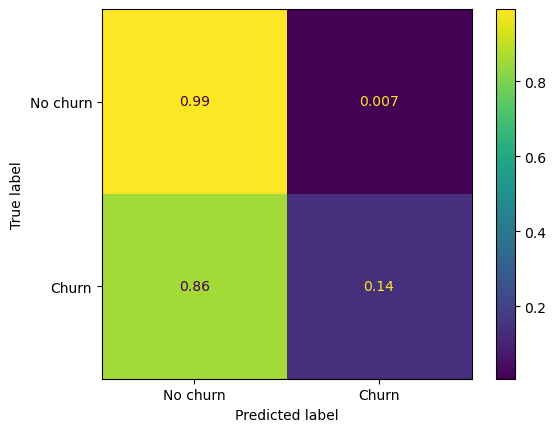

In [112]:
#Confusion matrix
cm_knn_pred = confusion_matrix(y_test, pred_knn, normalize = 'true')
disp_knn_pred = ConfusionMatrixDisplay(confusion_matrix = cm_knn_pred, display_labels = ['No churn', 'Churn'])
disp_knn_pred.plot()
plt.show()

### Interpretation

KNN works by estimating $P(Y = K | X = X_0)$ as the proportion of the K nearest neighbours belonging to class k. The model then predicts the class with the most votes. As with other models, few K neighbours allows the model to be flexible around a single point, overfitting that point, increasing variance. A high K allows the model to adjust over multiple K neigbours, reducing variance, but increasing bias, resulting in underfitting.

GridSearchCV finds the optimal K via 5-fold CV on the training data. We get a test performance of 168.

We see that the KNN model has a slightly higher accuracy of 87.4%, compared to the logistic regressions accuracy of 86.7%.

### d) Classification tree
***

In [113]:
#Classification tree
tree_clf = DecisionTreeClassifier(min_samples_leaf = 15, max_depth = 5, random_state = 0)
tree_clf.fit(X_train, y_train)

pred_tcf  = tree_clf.predict(X_test)
prob_tcf  = tree_clf.predict_proba(X_test)[:, 1]

accuracy_clf_tree = np.mean(pred_tcf == y_test)
print(f'Tree Accuracy: {accuracy_clf_tree:.4f}')

mse_tree_clf = np.sum((y_test - pred_tcf) ** 2)
print(f"MSE classification tree: {mse_tree_clf:.4f}")

Tree Accuracy: 0.9257
MSE classification tree: 99.0000


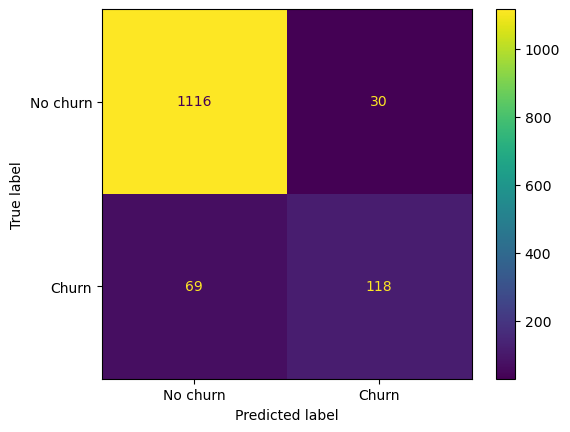

In [114]:
#Confusion matrix
cm_tree_clf = confusion_matrix(y_test, pred_tcf)
disp_cm_tree = ConfusionMatrixDisplay(confusion_matrix = cm_tree_clf, display_labels = ['No churn','Churn'])
disp_cm_tree.plot()
plt.show()

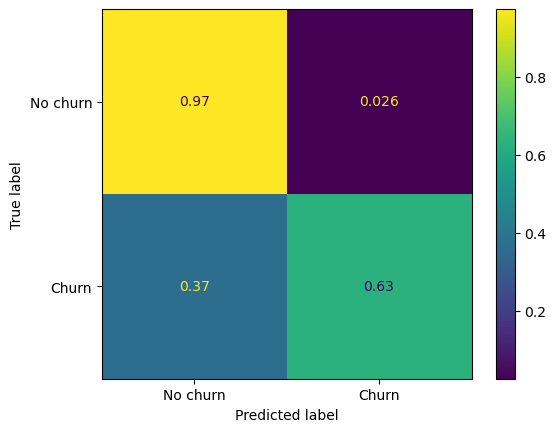

In [115]:
#Confusion matrix
cm_tree_pred = confusion_matrix(y_test, pred_tcf, normalize = 'true')
disp_cm_tree_pred = ConfusionMatrixDisplay(confusion_matrix = cm_tree_pred, display_labels = ['No churn', 'Churn'])
disp_cm_tree_pred.plot()
plt.show()

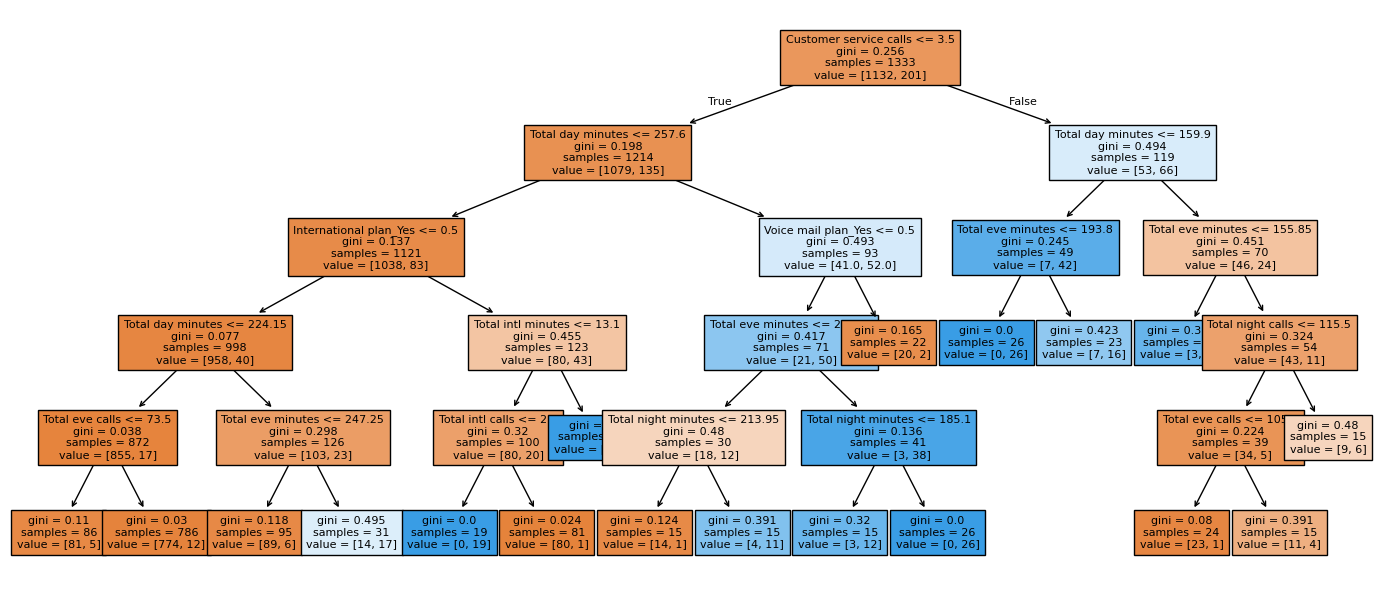

In [116]:
#Plot of classification tree
plt.figure(figsize=(14, 6))
plot_tree(tree_clf, feature_names=X_train.columns, filled=True, fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation

The classification tree splits data into binary classes, recursively predicting the majority class or probability of each leaf. I didnt have time to experiment with `min_leaf_samples` and `max_depth`, so i put it rather defensivley, as a unlimited tree will overfit and create leafs with only 1 sample and gain high variance. This tree uses gini as splitting criterion, meaning that a low gini indicates a pure node, with a dominant class. The tree splits to minimise gini, or to purify nodes/ leafs.

The tree chooses the split that minimizes residual sum of squares recursively. This is defined as $\sum(R1 - \bar{R1})^2 + \sum(R2 - \bar{R2})^2$.

The model identifies groups of customers with high churn risk by binarily splitting into groups based on variables given. We can follow the trees prediction to check if a certain group has higher values of churn rate than others. For example, customers who calls customer service often has a higher churn rate, indicated by the tree.

The classification tree has a MSE of 99, and a accuracy of 92.6. It captures 118 of 187 churners, giving a 64% hitrate. 

In [117]:
# #First split calculation
# def RSS_split(s, x, y):
#     R1 = y[x < s]
#     R2 = y[x >= s]
#     if len(R1) == 0 or len(R2) == 0:
#         return np.inf
#     return np.sum((R1 - R1.mean()) ** 2) + np.sum((R2 - R2.mean()) ** 2)

### e) Random forest
***

In [118]:
rfc = RandomForestClassifier(n_estimators = 500,
                             max_features = 'sqrt',
                             random_state = 123)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [119]:
prob_rfc  = rfc.predict_proba(X_test)[:, 1]
pred_rfc  = (prob_rfc > 0.5).astype(int)

accuracy_rf = np.mean(pred_rfc == y_test)
print(f'RF Accuracy: {accuracy_rf:.4f}')

mse_rfc = np.sum((y_test - pred_rfc) ** 2)
print(f"MSE random forest: {mse_rfc:.4f}")

RF Accuracy: 0.9377
MSE random forest: 83.0000


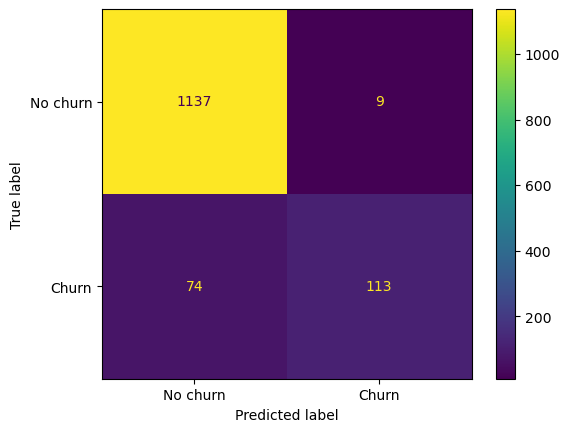

In [120]:
#Confusion matrix
cm_rfc = confusion_matrix(y_test, pred_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix = cm_rfc, display_labels = ['No churn', 'Churn'])
disp_rfc.plot()
plt.show()

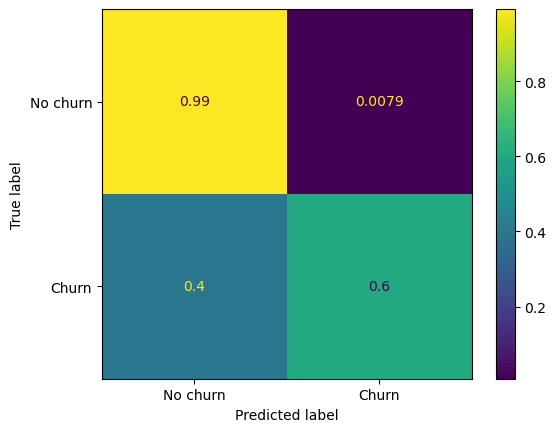

In [121]:
#Confusion matrix
cm_rfc_pred = confusion_matrix(y_test, pred_rfc, normalize = 'true')
disp_rfc_pred = ConfusionMatrixDisplay(confusion_matrix = cm_rfc_pred, display_labels = ['No churn', 'Churn'])
disp_rfc_pred.plot()
plt.show()

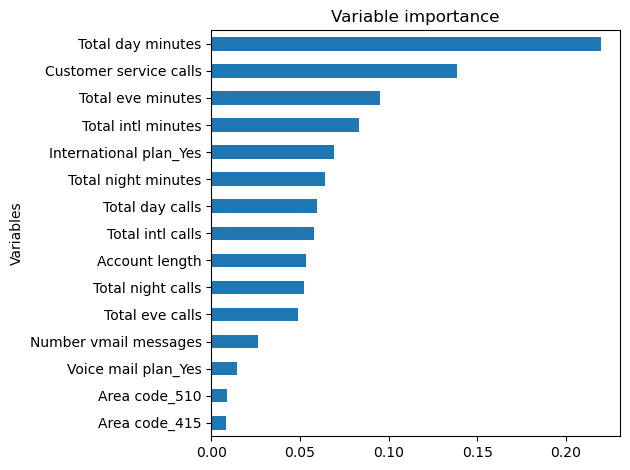

In [122]:
pd.Series(rfc.feature_importances_, index = X_train.columns).sort_values().plot.barh()
plt.title('Variable importance')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### Interpretation

The test performance gives a MSE of 83, which is better than both classification tree (99) and KNN (168). The accuracy of the model is at 93.8%, and captures 113 of 187 churners. This is a rate of 60%.

The most important predictors are `Total day minutes` (≈ 22%), `Customer service calls` (≈ 14%), `Total eve minutes` (≈ 9%), `Total intl minutes` (≈ 8%) and `International plan_Yes` (≈ 7%). This is consitent with our previous findings for the variables. 

The added accuracy and MSE is due to random forests ability to capture non-linearity. Random forest trains on (as Bagging) a lot of trees (as opposed to classifications 1 tree). For each iteration, the model uses a random selection of predictors for each split.

### f) Boosted tree
***

In [123]:
gbc = GradientBoostingClassifier(n_estimators=1000,
                                  learning_rate=0.01,
                                  max_depth=2,
                                  random_state=123)
gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [124]:
prob_gbc  = gbc.predict_proba(X_test)[:, 1]
pred_gbc  = (prob_gbc > 0.5).astype(int)

accuracy_boosted = np.mean(pred_gbc == y_test)
print(f'GBC Accuracy: {accuracy_boosted:.4f}')

mse_boost = np.sum((y_test - pred_gbc) ** 2)
print(f"MSE for boosted tree: {mse_boost:.4f}")

GBC Accuracy: 0.9280
MSE for boosted tree: 96.0000


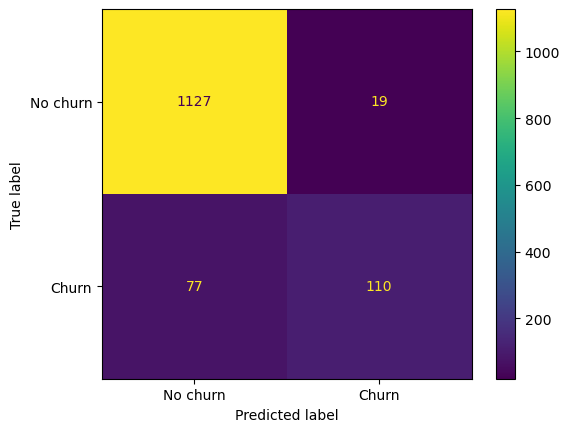

In [125]:
#Confusion matrix
cm_boost = confusion_matrix(y_test, pred_gbc)
disp_cm_boost = ConfusionMatrixDisplay(confusion_matrix = cm_boost, display_labels = ['No churn', 'Churn'])
disp_cm_boost.plot()
plt.show()

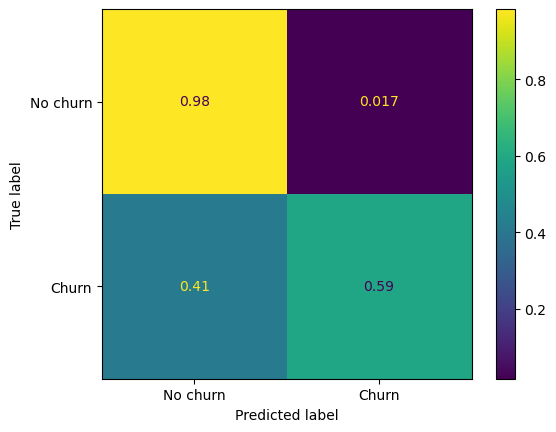

In [126]:
#Confusion matrix
cm_boost_clf = confusion_matrix(y_test, pred_gbc, normalize = 'true')
disp_cm_boot_clf = ConfusionMatrixDisplay(confusion_matrix = cm_boost_clf, display_labels = ['No churn', 'Churn'])
disp_cm_boot_clf.plot()
plt.show()

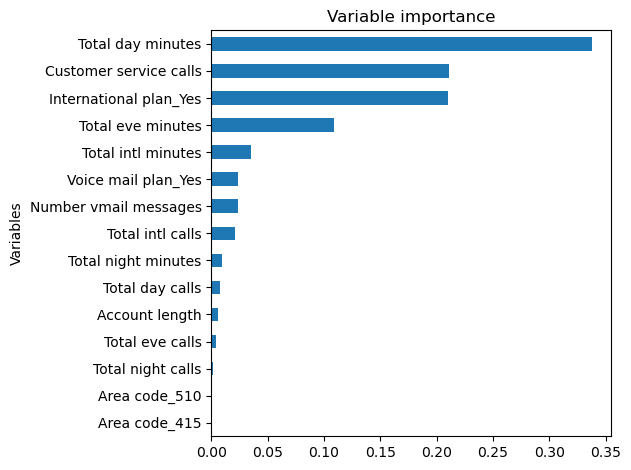

In [127]:
#Variable importance for boosted tree
pd.Series(gbc.feature_importances_, index = X_train.columns).sort_values().plot.barh()
plt.title('Variable importance')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### Interpretation

The test performance for the boosted tree is 96, with a accuracy of 92.9%. This is better than classification tree (99) and KNN (168), but worse than random forest. The model captures 110 of 187 churners, giving a rate og 59%. 

For boosted tree, the most important variables are `Total day minutes` (≈ 34%), `Customer service calls`(≈ 22%), `International plan_Yes`(≈ 22%) and `Total eve minutes`(≈ 12%). 

Boosted tree should have a good MSE and accuracy, as each tree is built sequentially, and each new tree is correcting the last one.

### g) Recommendation
***

In [128]:
#Results
results = pd.DataFrame({
    'Model' : ['Naive (always false)', 'Logistisk regression', 'KNN', 'Classification tree', 'Random forest', 'Boosted'],
    'Accuracy' : [1 - y_test.mean(), accuracy_logreg, accuracy_knn, accuracy_clf_tree, accuracy_rf, accuracy_boosted],
    'Error rate' : [y_test.mean(), mse_log, mse_knn, mse_tree_clf, mse_rfc, mse_boost]
})

results = results.sort_values('Error rate').reset_index(drop = True)
print(results)

                  Model  Accuracy  Error rate
0  Naive (always false)  0.859715    0.140285
1         Random forest  0.937734   83.000000
2               Boosted  0.927982   96.000000
3   Classification tree  0.925731   99.000000
4                   KNN  0.873968  168.000000
5  Logistisk regression  0.867217  177.000000


For the purpose of analysing and modelling the dataset, i would recommend using the random forest model. 
As we can see in the table above, it has both the highest accuracy and lowest error rate of all models. 

Throughout the analysis we have found that variables such as `customer service calls` and `Total day minutes` are of importance. Customers that call more often has, as we can see from the boxplot, higher rates of churning. 
Other variables, such as `Account length` and `Total intl minutes` does not show the same importance for explaining the variance in churning rates. 

This information could be used to focus your attention towards these metrics. For example, how could you decrease the number of customer service calls, so that the number of customers who churn might be reduced? And how does the `Total day minutes` affect the amount of customers churning.

A limitation or risk of this method is leakage of data. If the data is not handled correctly to avoid for example bias-leakage, the regression wont be of any meaningful value.